In [1]:
import os
import json
import cv2
import numpy as np

DATA_PATH = "Data/Hurricane"
IMG_SIZE = 224

X_cnn = []
y_cnn = []

for json_file in os.listdir(f"{DATA_PATH}/JSON"):
    
    with open(f"{DATA_PATH}/JSON/{json_file}") as f:
        data = json.load(f)

    frame_path = os.path.join(DATA_PATH, data["Frame_Name"])
    image = cv2.imread(frame_path)

    if image is None:
        print("Could not read image:", frame_path)
        continue

    # OpenCV loads as BGR, convert to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0

    for building in data["Buildings"]:
        
        mask_filename = building[2]
        label = building[3]

        mask_path = os.path.join(DATA_PATH, "MASK", mask_filename)

        if not os.path.exists(mask_path):
            continue

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if mask is None:
            print("Could not read mask:", mask_path)
            continue

        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = mask / 255.0
        mask = np.expand_dims(mask, axis=-1)

        # Combine RGB image + mask channel
        combined = np.concatenate([image, mask], axis=-1)

        X_cnn.append(combined)
        y_cnn.append(label)

X_cnn = np.array(X_cnn, dtype=np.float32)
y_cnn = np.array(y_cnn, dtype=np.int64)

print("X_cnn shape:", X_cnn.shape)
print("y_cnn shape:", y_cnn.shape)
print("Labels:", sorted(set(y_cnn)))

X_cnn shape: (1458, 224, 224, 4)
y_cnn shape: (1458,)
Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [2]:
from sklearn.model_selection import train_test_split

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn,
    y_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_cnn
)

print("X_train_cnn:", X_train_cnn.shape)
print("X_test_cnn:", X_test_cnn.shape)
print("y_train_cnn:", y_train_cnn.shape)
print("y_test_cnn:", y_test_cnn.shape)

X_train_cnn: (1166, 224, 224, 4)
X_test_cnn: (292, 224, 224, 4)
y_train_cnn: (1166,)
y_test_cnn: (292,)


In [4]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_cnn)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_cnn
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

print(class_weights)

{0: 1.4502487562189055, 1: 0.9210110584518167, 2: 1.237791932059448, 3: 0.5238095238095238, 4: 0.9433656957928802, 5: 2.2337164750957856}


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(np.unique(y_cnn))

cnn = models.Sequential([
    layers.Input(shape=(224, 224, 4)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993,638 (19.05 MB)

 Trainable params: 4,993,638 (19.05 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = cnn.fit(
    X_train_cnn,
    y_train_cnn,
    validation_split=0.2,
    epochs=30,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.2264 - loss: 1.7934 - val_accuracy: 0.2863 - val_loss: 1.7749
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.2650 - loss: 1.7506 - val_accuracy: 0.1923 - val_loss: 1.7634
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - accuracy: 0.3348 - loss: 1.6291 - val_accuracy: 0.2521 - val_loss: 1.7208
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.4045 - loss: 1.5178 - val_accuracy: 0.3205 - val_loss: 1.6368
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - accuracy: 0.4635 - loss: 1.3749 - val_accuracy: 0.3590 - val_loss: 1.6108
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.5161 - loss: 1.2435 - val_accuracy: 0.3462 - val_loss: 1.6671
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step - accuracy: 0.5418 - loss: 1.1021 - val_accuracy: 0.4145 - val_loss: 1.7303
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.6041 - loss: 0.9677 - val_accuracy:

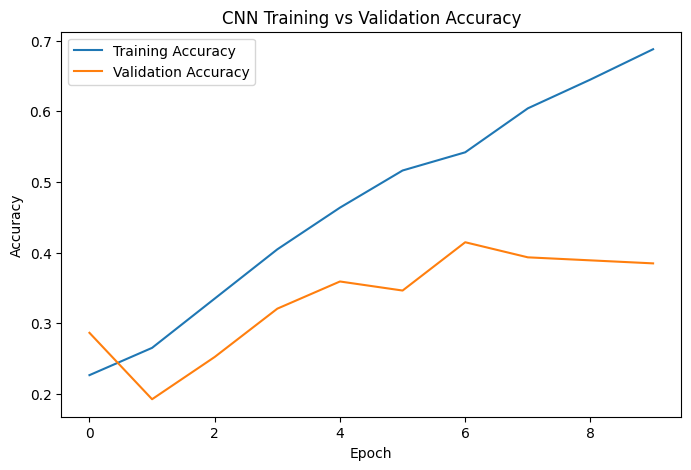

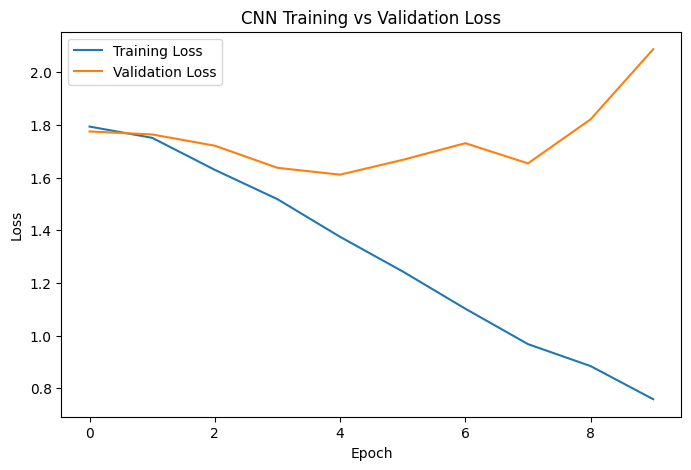

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.show()

In [9]:
test_loss, test_acc = cnn.evaluate(X_test_cnn, y_test_cnn, verbose=0)

print("CNN Test Loss:", test_loss)
print("CNN Test Accuracy:", test_acc)

CNN Test Loss: 1.4987893104553223
CNN Test Accuracy: 0.42465752363204956


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
              precision    recall  f1-score   support

           0       0.28      0.32      0.30        34
           1       0.55      0.53      0.54        53
           2       0.35      0.38      0.37        39
           3       0.57      0.41      0.47        93
           4       0.38      0.40      0.39        52
           5       0.31      0.52      0.39        21

    accuracy                           0.42       292
   macro avg       0.40      0.43      0.41       292
weighted avg       0.45      0.42      0.43       292



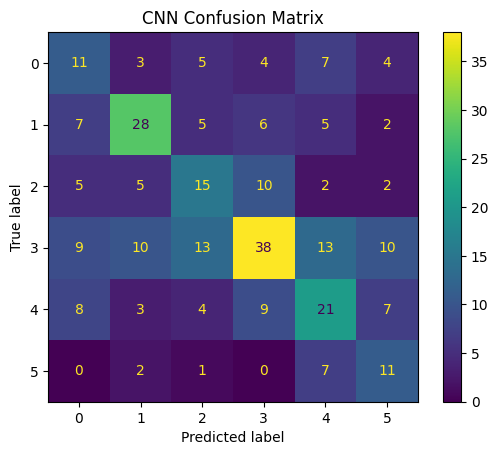

In [10]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_pred_probs = cnn.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test_cnn, y_pred_cnn))

ConfusionMatrixDisplay.from_predictions(y_test_cnn, y_pred_cnn)
plt.title("CNN Confusion Matrix")
plt.show()

In [11]:
def within_one_accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred) <= 1)

cnn_pm1_acc = within_one_accuracy(y_test_cnn, y_pred_cnn)

print("CNN Strict Accuracy:", test_acc)
print("CNN ±1 Class Accuracy:", cnn_pm1_acc)

CNN Strict Accuracy: 0.42465752363204956
CNN ±1 Class Accuracy: 0.6952054794520548


In [13]:
import pandas as pd

cnn_results = pd.DataFrame([
    {
        "Model": "CNN",
        "Strict Accuracy": test_acc,
        "±1 Class Accuracy": cnn_pm1_acc,
        "Test Loss": test_loss
    }
])

cnn_results

,Model,Strict Accuracy,±1 Class Accuracy,Test Loss
0,CNN,0.424658,0.695205,1.498789


In [14]:

num_classes = len(np.unique(y_cnn))

cnn_small = models.Sequential([
    layers.Input(shape=(224, 224, 4)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

cnn_small.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_small.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 4)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,814 (1014.90 KB)

 Trainable params: 259,110 (1012.15 KB)

 Non-trainable params: 704 (2.75 KB)

In [15]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history_small = cnn_small.fit(
    X_train_cnn,
    y_train_cnn,
    validation_split=0.2,
    epochs=40,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 17s 252ms/step - accuracy: 0.2124 - loss: 1.8453 - val_accuracy: 0.1453 - val_loss: 1.7888 - learning_rate: 3.0000e-04
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 254ms/step - accuracy: 0.2082 - loss: 1.7679 - val_accuracy: 0.2521 - val_loss: 1.9163 - learning_rate: 3.0000e-04
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 250ms/step - accuracy: 0.2328 - loss: 1.7776 - val_accuracy: 0.2051 - val_loss: 2.0359 - learning_rate: 3.0000e-04
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 254ms/step - accuracy: 0.2543 - loss: 1.7385 - val_accuracy: 0.2735 - val_loss: 2.1034 - learning_rate: 3.0000e-04
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 264ms/step - accuracy: 0.2157 - loss: 1.7165 - val_accuracy: 0.2692 - val_loss: 2.1854 - learning_rate: 1.5000e-04
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 268ms/step - accuracy: 0.2436 - loss: 1.6947 - val_accuracy: 0.2692 - val_loss: 2.1939 - learning_rate: 1.5000e-04
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 267ms/step - acc

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
Improved CNN Test Loss: 1.7967313528060913
Improved CNN Test Accuracy: 0.1335616409778595
Improved CNN ±1 Class Accuracy: 0.6335616438356164
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        34
           1       0.00      0.00      0.00        53
           2       0.13      1.00      0.24        39
           3       0.00      0.00      0.00        93
           4       0.00      0.00      0.00        52
           5       0.00      0.00      0.00        21

    accuracy                           0.13       292
   macro avg       0.02      0.17      0.04       292
weighted avg       0.02      0.13      0.03       292



/Users/luisromero/Desktop/Spring 2026/AI/FinalProject/AI-Final-Project-GroupRRM/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luisromero/Desktop/Spring 2026/AI/FinalProject/AI-Final-Project-GroupRRM/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luisromero/Desktop/Spring 2026/AI/FinalProject/AI-Final-Project-GroupRRM/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

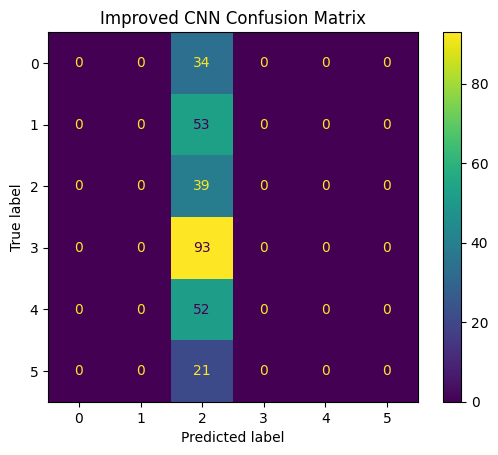

In [16]:
test_loss_small, test_acc_small = cnn_small.evaluate(X_test_cnn, y_test_cnn, verbose=0)

y_pred_probs_small = cnn_small.predict(X_test_cnn)
y_pred_small = np.argmax(y_pred_probs_small, axis=1)

pm1_acc_small = within_one_accuracy(y_test_cnn, y_pred_small)

print("Improved CNN Test Loss:", test_loss_small)
print("Improved CNN Test Accuracy:", test_acc_small)
print("Improved CNN ±1 Class Accuracy:", pm1_acc_small)

print(classification_report(y_test_cnn, y_pred_small))

ConfusionMatrixDisplay.from_predictions(y_test_cnn, y_pred_small)
plt.title("Improved CNN Confusion Matrix")
plt.show()

In [ ]:
### The second CNN architecture with batch normalization and global average pooling performed worse than the original CNN. 
### It collapsed into predicting mostly one class, so it was not selected as the final model.


cnn_comparison = pd.DataFrame([
    {
        "Model": "Original CNN",
        "Strict Accuracy": test_acc,
        "±1 Class Accuracy": cnn_pm1_acc,
        "Test Loss": test_loss
    },
    {
        "Model": "Improved CNN",
        "Strict Accuracy": test_acc_small,
        "±1 Class Accuracy": pm1_acc_small,
        "Test Loss": test_loss_small
    }
])

cnn_comparison

,Model,Strict Accuracy,±1 Class Accuracy,Test Loss
0,Original CNN,0.424658,0.695205,1.498789
1,Improved CNN,0.133562,0.633562,1.796731


In [18]:
import numpy as np

num_classes = len(np.unique(y_cnn))

cnn_v2 = models.Sequential([
    layers.Input(shape=(224, 224, 4)),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.6),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation="softmax")
])

cnn_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 4)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,697,574 (25.55 MB)

 Trainable params: 6,697,574 (25.55 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history_v2 = cnn_v2.fit(
    X_train_cnn,
    y_train_cnn,
    validation_split=0.2,
    epochs=40,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 181ms/step - accuracy: 0.1513 - loss: 1.7981 - val_accuracy: 0.2692 - val_loss: 1.7915 - learning_rate: 3.0000e-04
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - accuracy: 0.2049 - loss: 1.7895 - val_accuracy: 0.2265 - val_loss: 1.7890 - learning_rate: 3.0000e-04
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 191ms/step - accuracy: 0.2146 - loss: 1.7879 - val_accuracy: 0.2906 - val_loss: 1.7844 - learning_rate: 3.0000e-04
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 190ms/step - accuracy: 0.1749 - loss: 1.7790 - val_accuracy: 0.2222 - val_loss: 1.7662 - learning_rate: 3.0000e-04
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step - accuracy: 0.2135 - loss: 1.7762 - val_accuracy: 0.2265 - val_loss: 1.7740 - learning_rate: 3.0000e-04
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.2371 - loss: 1.7678 - val_accuracy: 0.1581 - val_loss: 1.7701 - learning_rate: 3.0000e-04
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 200ms/step - acc

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step
CNN v2 Test Loss: 1.6228904724121094
CNN v2 Test Accuracy: 0.3047945201396942
CNN v2 ±1 Class Accuracy: 0.5616438356164384
              precision    recall  f1-score   support

           0       0.25      0.38      0.31        34
           1       0.34      0.32      0.33        53
           2       0.21      0.21      0.21        39
           3       0.51      0.31      0.39        93
           4       0.32      0.25      0.28        52
           5       0.16      0.43      0.24        21

    accuracy                           0.30       292
   macro avg       0.30      0.32      0.29       292
weighted avg       0.35      0.30      0.31       292



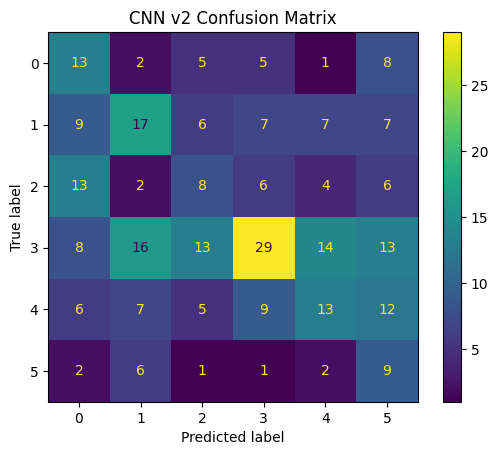

In [20]:
test_loss_v2, test_acc_v2 = cnn_v2.evaluate(X_test_cnn, y_test_cnn, verbose=0)

y_pred_probs_v2 = cnn_v2.predict(X_test_cnn)
y_pred_v2 = np.argmax(y_pred_probs_v2, axis=1)

pm1_acc_v2 = within_one_accuracy(y_test_cnn, y_pred_v2)

print("CNN v2 Test Loss:", test_loss_v2)
print("CNN v2 Test Accuracy:", test_acc_v2)
print("CNN v2 ±1 Class Accuracy:", pm1_acc_v2)

print(classification_report(y_test_cnn, y_pred_v2, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test_cnn, y_pred_v2)
plt.title("CNN v2 Confusion Matrix")
plt.show()

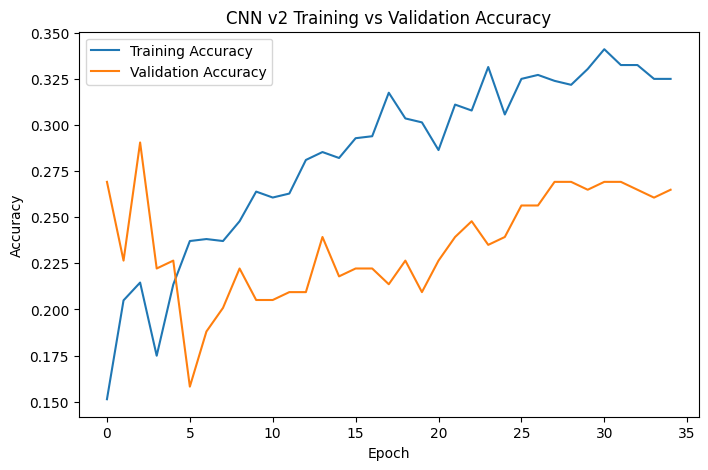

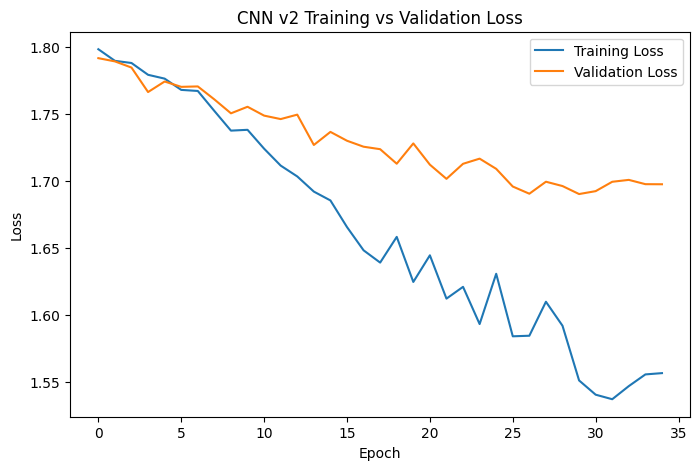

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history_v2.history["accuracy"], label="Training Accuracy")
plt.plot(history_v2.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN v2 Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_v2.history["loss"], label="Training Loss")
plt.plot(history_v2.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN v2 Training vs Validation Loss")
plt.legend()
plt.show()

In [22]:
cnn_comparison = pd.DataFrame([
    {
        "Model": "Original CNN",
        "Strict Accuracy": test_acc,
        "±1 Class Accuracy": cnn_pm1_acc,
        "Test Loss": test_loss
    },
    {
        "Model": "CNN v2",
        "Strict Accuracy": test_acc_v2,
        "±1 Class Accuracy": pm1_acc_v2,
        "Test Loss": test_loss_v2
    }
])

cnn_comparison

,Model,Strict Accuracy,±1 Class Accuracy,Test Loss
0,Original CNN,0.424658,0.695205,1.498789
1,CNN v2,0.304795,0.561644,1.622890


### Trying another CNN

In [23]:

num_classes = len(np.unique(y_cnn))

cnn_v3 = models.Sequential([
    layers.Input(shape=(224, 224, 4)),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation="softmax")
])

cnn_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_v3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 224, 224, 4)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,374 (1.61 MB)

 Trainable params: 422,374 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history_v3 = cnn_v3.fit(
    X_train_cnn,
    y_train_cnn,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step - accuracy: 0.1738 - loss: 1.7917 - val_accuracy: 0.2735 - val_loss: 1.7897 - learning_rate: 3.0000e-04
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 195ms/step - accuracy: 0.2307 - loss: 1.7883 - val_accuracy: 0.2692 - val_loss: 1.7876 - learning_rate: 3.0000e-04
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 205ms/step - accuracy: 0.1996 - loss: 1.7836 - val_accuracy: 0.2222 - val_loss: 1.7865 - learning_rate: 3.0000e-04
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 207ms/step - accuracy: 0.2082 - loss: 1.7778 - val_accuracy: 0.1795 - val_loss: 1.7928 - learning_rate: 3.0000e-04
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 205ms/step - accuracy: 0.2350 - loss: 1.7730 - val_accuracy: 0.1368 - val_loss: 1.7911 - learning_rate: 3.0000e-04
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 211ms/step - accuracy: 0.1964 - loss: 1.7717 - val_accuracy: 0.2137 - val_loss: 1.7764 - learning_rate: 3.0000e-04
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 211ms/step - acc

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step
CNN v3 Test Loss: 1.7384344339370728
CNN v3 Test Accuracy: 0.19863013923168182
CNN v3 ±1 Class Accuracy: 0.4212328767123288
              precision    recall  f1-score   support

           0       0.13      0.06      0.08        34
           1       0.19      0.60      0.29        53
           2       0.18      0.10      0.13        39
           3       0.24      0.22      0.23        93
           4       0.00      0.00      0.00        52
           5       0.00      0.00      0.00        21

    accuracy                           0.20       292
   macro avg       0.12      0.16      0.12       292
weighted avg       0.15      0.20      0.15       292



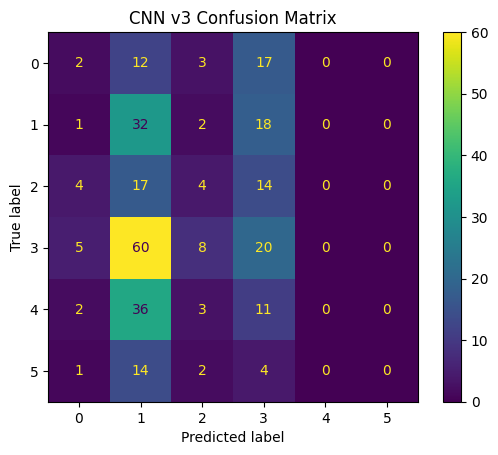

In [25]:
test_loss_v3, test_acc_v3 = cnn_v3.evaluate(X_test_cnn, y_test_cnn, verbose=0)

y_pred_probs_v3 = cnn_v3.predict(X_test_cnn)
y_pred_v3 = np.argmax(y_pred_probs_v3, axis=1)

pm1_acc_v3 = within_one_accuracy(y_test_cnn, y_pred_v3)

print("CNN v3 Test Loss:", test_loss_v3)
print("CNN v3 Test Accuracy:", test_acc_v3)
print("CNN v3 ±1 Class Accuracy:", pm1_acc_v3)

print(classification_report(y_test_cnn, y_pred_v3, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test_cnn, y_pred_v3)
plt.title("CNN v3 Confusion Matrix")
plt.show()

In [26]:
cnn_comparison = pd.DataFrame([
    {
        "Model": "Original CNN",
        "Strict Accuracy": test_acc,
        "±1 Class Accuracy": cnn_pm1_acc,
        "Test Loss": test_loss
    },
    {
        "Model": "CNN v2",
        "Strict Accuracy": test_acc_v2,
        "±1 Class Accuracy": pm1_acc_v2,
        "Test Loss": test_loss_v2
    },
    {
        "Model": "CNN v3",
        "Strict Accuracy": test_acc_v3,
        "±1 Class Accuracy": pm1_acc_v3,
        "Test Loss": test_loss_v3
    }
])

cnn_comparison

,Model,Strict Accuracy,±1 Class Accuracy,Test Loss
0,Original CNN,0.424658,0.695205,1.498789
1,CNN v2,0.304795,0.561644,1.622890
2,CNN v3,0.198630,0.421233,1.738434


## CNN Model Comparison

Three CNN architectures were tested. The original CNN performed the best overall, achieving the highest strict accuracy, highest ±1 class accuracy, and lowest test loss. CNN v2 and CNN v3 were intended to reduce overfitting through augmentation, dropout, and architectural changes, but both performed worse on the test set.

Because the original CNN had the best overall performance, it was selected as the final neural network model.